# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Retails Operations Dataset](https://www.kaggle.com/datasets/rahulkumar37841/e-commerce-customer-and-order-insights)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.	

# Importing

## Import Library

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('customer_data.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,Customer ID,Age,Gender,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
0,2701,22,Female,68.0,California,XL,Olive,Winter,3.2,No,No,36.0,Cash,Weekly
1,521,51,Male,84.0,South Carolina,M,White,Spring,3.9,Yes,Yes,20.0,Debit Card,Quarterly
2,3157,18,Female,50.0,Montana,M,Black,Winter,3.1,No,No,18.0,Cash,Monthly
3,1687,22,Male,75.0,Illinois,L,Red,Fall,4.2,No,No,25.0,Cash,Annually
4,2929,40,Female,80.0,Alabama,L,Yellow,Spring,3.6,No,No,17.0,Credit Card,Weekly


## last Five row

In [4]:
df.tail()

,Customer ID,Age,Gender,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
5045,913,24,Male,56.0,Arkansas,M,Green,Winter,3.4,Yes,Yes,32.0,Bank Transfer,Monthly
5046,3466,19,Female,53.0,Iowa,M,Gold,Spring,3.4,No,No,31.0,Debit Card,Weekly
5047,3572,70,Female,27.0,North Dakota,M,White,Summer,3.2,No,No,15.0,Bank Transfer,Every 3 Months
5048,3195,43,Female,52.0,Maryland,L,Gold,Summer,4.6,No,No,10.0,Credit Card,Bi-Weekly
5049,1832,62,Male,71.0,Maine,M,Cyan,Summer,NaN,No,No,5.0,Bank Transfer,Every 3 Months


## Shape of our dataset

In [5]:
df.shape

(5050, 14)

## List out all columns

In [6]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Purchase Amount (USD)', 'Location',
       'Size', 'Color', 'Season', 'Review Rating', 'Subscription Status',
       'Discount Applied', 'Previous Purchases', 'Payment Method',
       'Frequency of Purchases'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Customer ID                 int64
Age                         int64
Gender                     object
Purchase Amount (USD)     float64
Location                   object
Size                       object
Color                      object
Season                     object
Review Rating             float64
Subscription Status        object
Discount Applied           object
Previous Purchases        float64
Payment Method             object
Frequency of Purchases     object
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             5050 non-null   int64  
 1   Age                     5050 non-null   int64  
 2   Gender                  5050 non-null   object 
 3   Purchase Amount (USD)   4492 non-null   float64
 4   Location                5050 non-null   object 
 5   Size                    4676 non-null   object 
 6   Color                   5050 non-null   object 
 7   Season                  5050 non-null   object 
 8   Review Rating           4448 non-null   float64
 9   Subscription Status     5050 non-null   object 
 10  Discount Applied        5048 non-null   object 
 11  Previous Purchases      4502 non-null   float64
 12  Payment Method          5050 non-null   object 
 13  Frequency of Purchases  5050 non-null   object 
dtypes: float64(3), int64(2), object(9)
memor

## Check Null Value

In [9]:
df.isnull().sum()

Customer ID                 0
Age                         0
Gender                      0
Purchase Amount (USD)     558
Location                    0
Size                      374
Color                       0
Season                      0
Review Rating             602
Subscription Status         0
Discount Applied            2
Previous Purchases        548
Payment Method              0
Frequency of Purchases      0
dtype: int64

## fill numerical null values with median

In [10]:
df['Purchase Amount (USD)'] = df['Purchase Amount (USD)'].fillna(
    df['Purchase Amount (USD)'].median()
)

## fill size null values with most frequent value

In [11]:
df['Size'] = df['Size'].fillna(df['Size'].mode()[0])

## fill review rating null values with median

In [12]:
df['Review Rating'] = df['Review Rating'].fillna(
    df['Review Rating'].median()
)

## fill discount applied null values with most frequent value

In [13]:
df['Discount Applied'] = df['Discount Applied'].fillna(
    df['Discount Applied'].mode()[0]
)

## fill previous purchases null values with median

In [14]:
df['Previous Purchases'] = df['Previous Purchases'].fillna(
    df['Previous Purchases'].median()
)

## display remaining null values

In [15]:
print(df.isnull().sum())

Customer ID               0
Age                       0
Gender                    0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Discount Applied          0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64


## Check Dupicate Value

In [16]:
df.duplicated().sum()

np.int64(50)

## Summary

In [17]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,5050.000000,5050.000000,5050.000000,5050.000000,5050.000000
mean,2519.570891,44.150495,135.987123,3.672059,25.197822
std,1470.402964,15.282328,261.168791,0.812271,13.711117
min,1.000000,18.000000,10.120000,1.000000,0.000000
25%,1252.250000,31.000000,44.000000,3.100000,14.000000
50%,2499.500000,44.000000,65.000000,3.700000,25.000000
75%,3740.750000,57.000000,85.000000,4.300000,36.000000
max,5099.000000,70.000000,1499.760000,5.000000,50.000000


# EDA

In [18]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

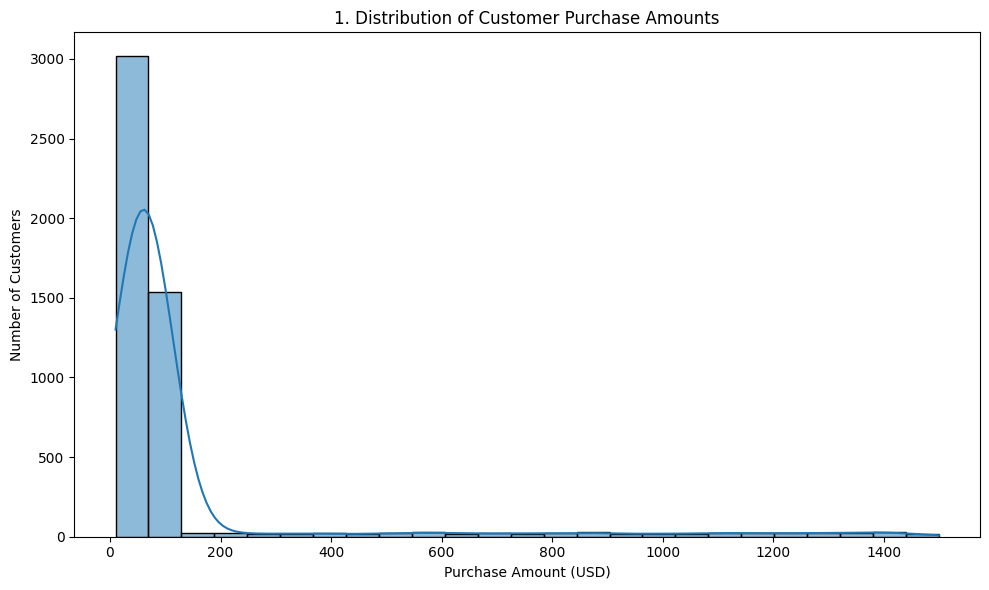

In [19]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Purchase Amount (USD)', bins=25, kde=True)
plt.title(f'{plot_no}. Distribution of Customer Purchase Amounts')
plt.xlabel('Purchase Amount (USD)')
plt.ylabel('Number of Customers')
show_fig()
plot_no += 1

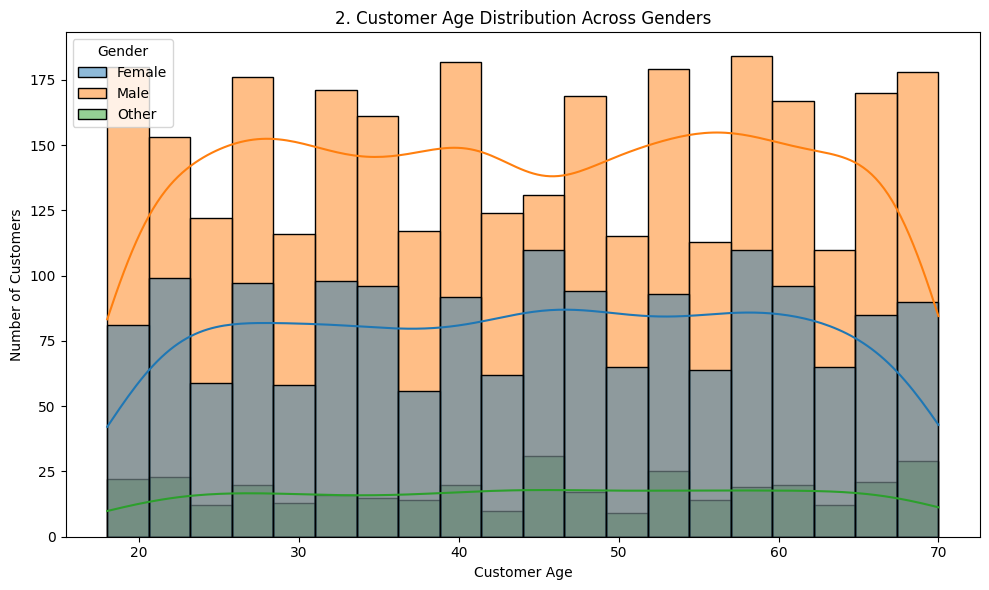

In [20]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Age', hue='Gender', bins=20, kde=True, multiple='layer')
plt.title(f'{plot_no}. Customer Age Distribution Across Genders')
plt.xlabel('Customer Age')
plt.ylabel('Number of Customers')
show_fig()
plot_no += 1

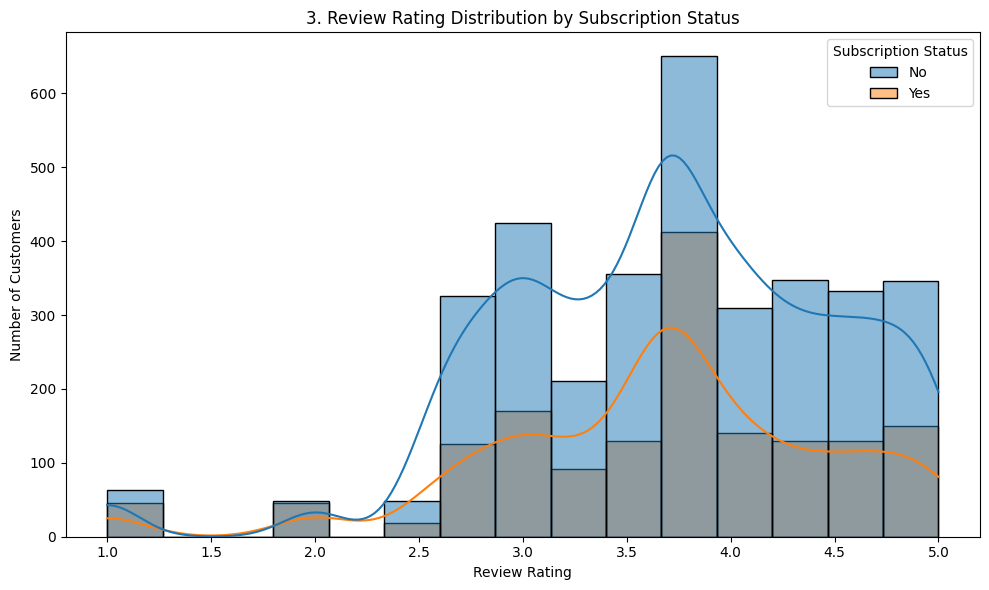

In [21]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Review Rating', hue='Subscription Status', bins=15, kde=True, multiple='layer')
plt.title(f'{plot_no}. Review Rating Distribution by Subscription Status')
plt.xlabel('Review Rating')
plt.ylabel('Number of Customers')
show_fig()
plot_no += 1

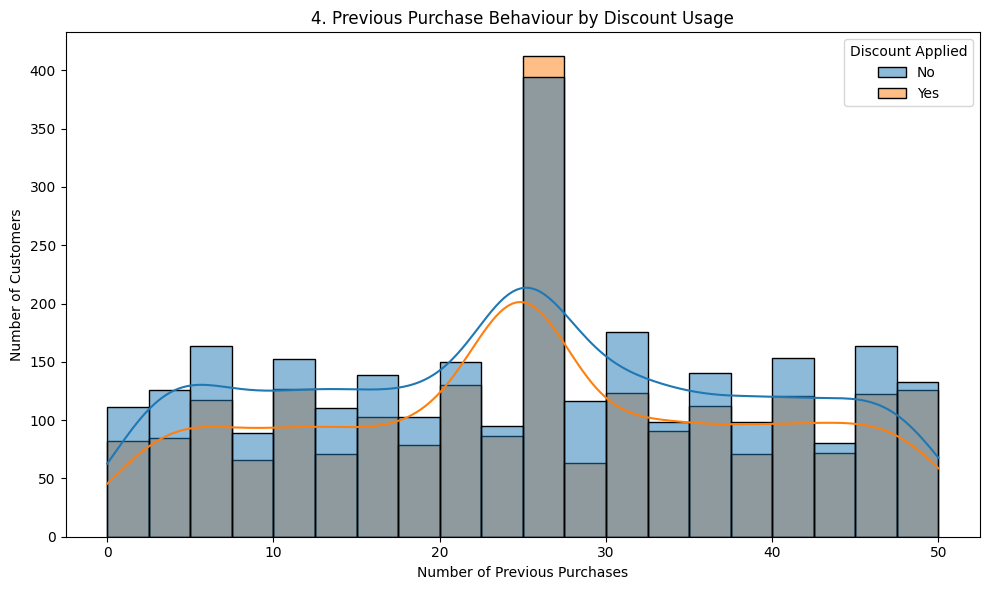

In [22]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Previous Purchases', hue='Discount Applied', bins=20, kde=True, multiple='layer')
plt.title(f'{plot_no}. Previous Purchase Behaviour by Discount Usage')
plt.xlabel('Number of Previous Purchases')
plt.ylabel('Number of Customers')
show_fig()
plot_no += 1

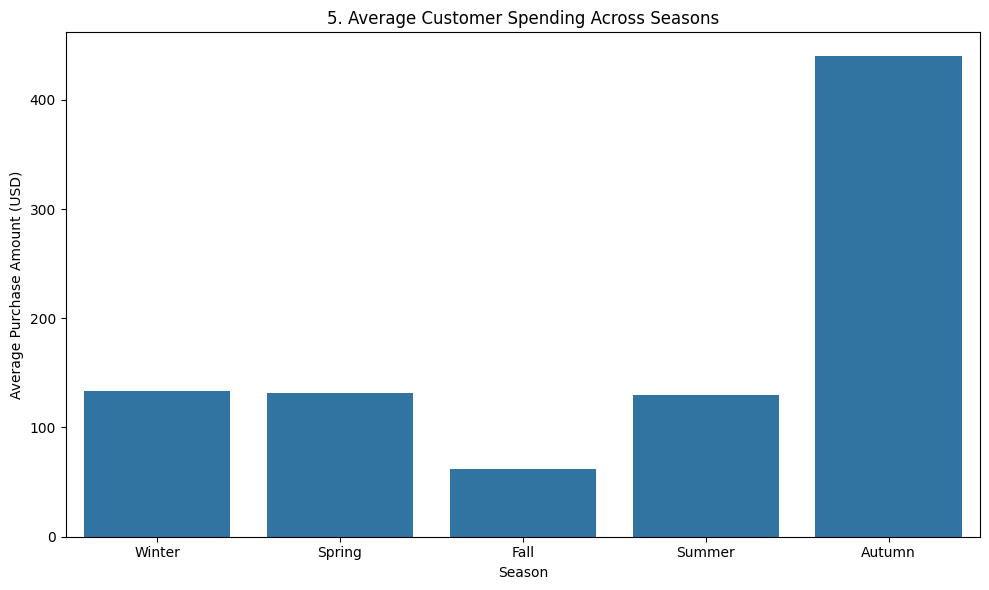

In [23]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Season', y='Purchase Amount (USD)', errorbar=None)
plt.title(f'{plot_no}. Average Customer Spending Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Purchase Amount (USD)')
show_fig()
plot_no += 1

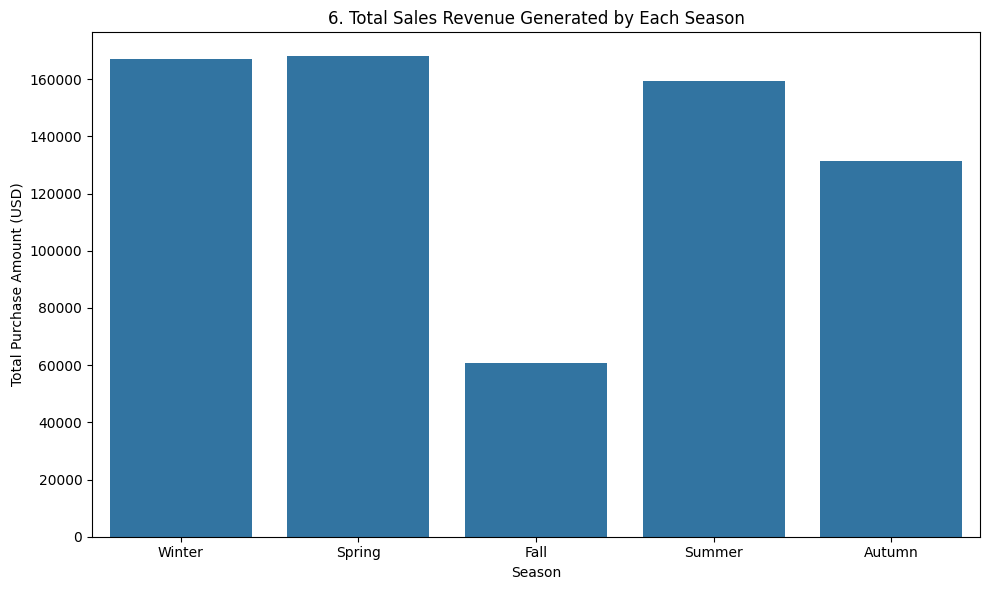

In [24]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Season', y='Purchase Amount (USD)', estimator=sum, errorbar=None)
plt.title(f'{plot_no}. Total Sales Revenue Generated by Each Season')
plt.xlabel('Season')
plt.ylabel('Total Purchase Amount (USD)')
show_fig()
plot_no += 1

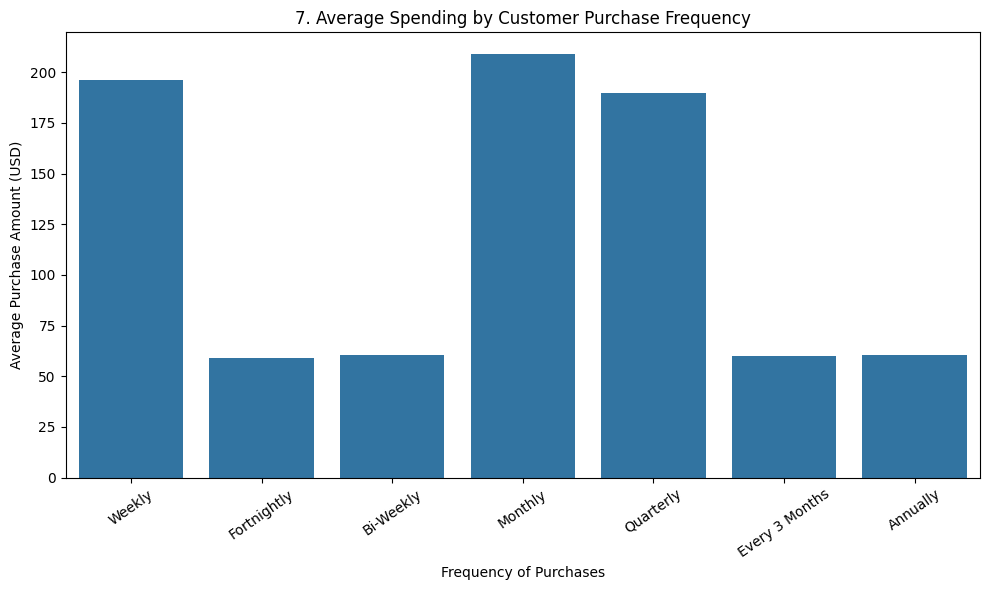

In [25]:
fig = plt.figure(figsize=(10,6))
frequency_order = ['Weekly', 'Fortnightly', 'Bi-Weekly', 'Monthly', 'Quarterly', 'Every 3 Months', 'Annually']
sns.barplot(data=df, x='Frequency of Purchases', y='Purchase Amount (USD)', order=frequency_order, errorbar=None)
plt.title(f'{plot_no}. Average Spending by Customer Purchase Frequency')
plt.xlabel('Frequency of Purchases')
plt.ylabel('Average Purchase Amount (USD)')
plt.xticks(rotation=35)
show_fig()
plot_no += 1

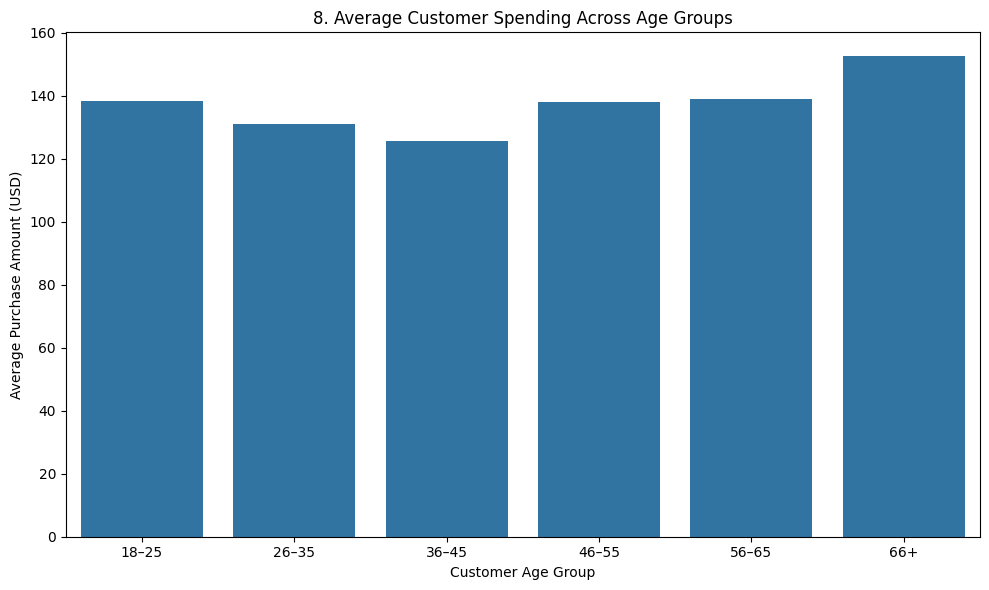

In [26]:
fig = plt.figure(figsize=(10,6))
age_analysis = df.assign(Age_Group=pd.cut(df['Age'], bins=[17, 25, 35, 45, 55, 65, float('inf')], labels=['18–25', '26–35', '36–45', '46–55', '56–65', '66+']))
sns.barplot(data=age_analysis, x='Age_Group', y='Purchase Amount (USD)', errorbar=None)
plt.title(f'{plot_no}. Average Customer Spending Across Age Groups')
plt.xlabel('Customer Age Group')
plt.ylabel('Average Purchase Amount (USD)')
show_fig()
plot_no += 1

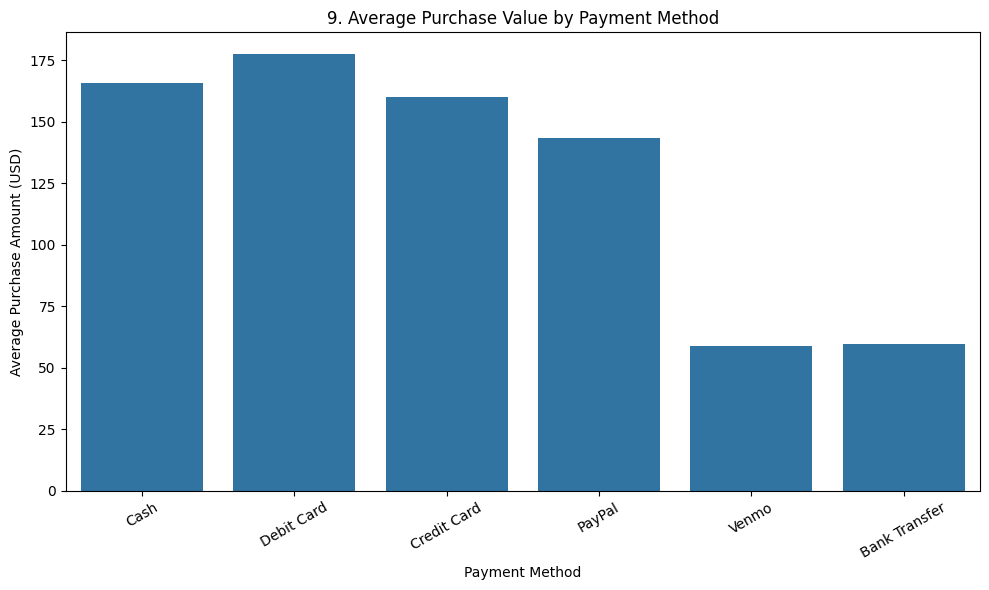

In [27]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Payment Method', y='Purchase Amount (USD)', errorbar=None)
plt.title(f'{plot_no}. Average Purchase Value by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Average Purchase Amount (USD)')
plt.xticks(rotation=30)
show_fig()
plot_no += 1

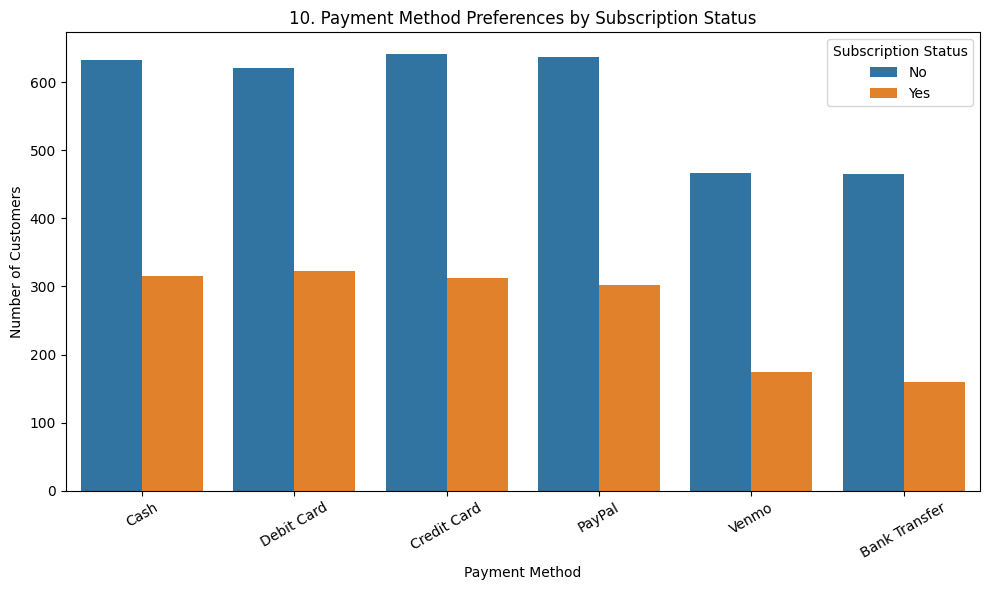

In [28]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Payment Method', hue='Subscription Status')
plt.title(f'{plot_no}. Payment Method Preferences by Subscription Status')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')
plt.xticks(rotation=30)
show_fig()
plot_no += 1

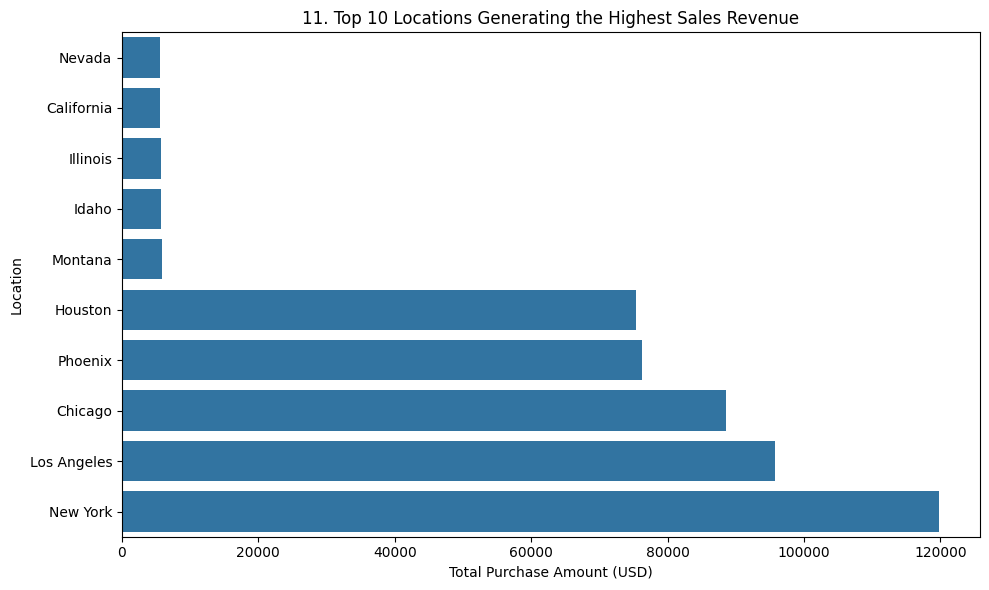

In [29]:
fig = plt.figure(figsize=(10,6))
location_sales = df.groupby('Location')['Purchase Amount (USD)'].sum().nlargest(10).sort_values()
sns.barplot(x=location_sales.values, y=location_sales.index)
plt.title(f'{plot_no}. Top 10 Locations Generating the Highest Sales Revenue')
plt.xlabel('Total Purchase Amount (USD)')
plt.ylabel('Location')
show_fig()
plot_no += 1

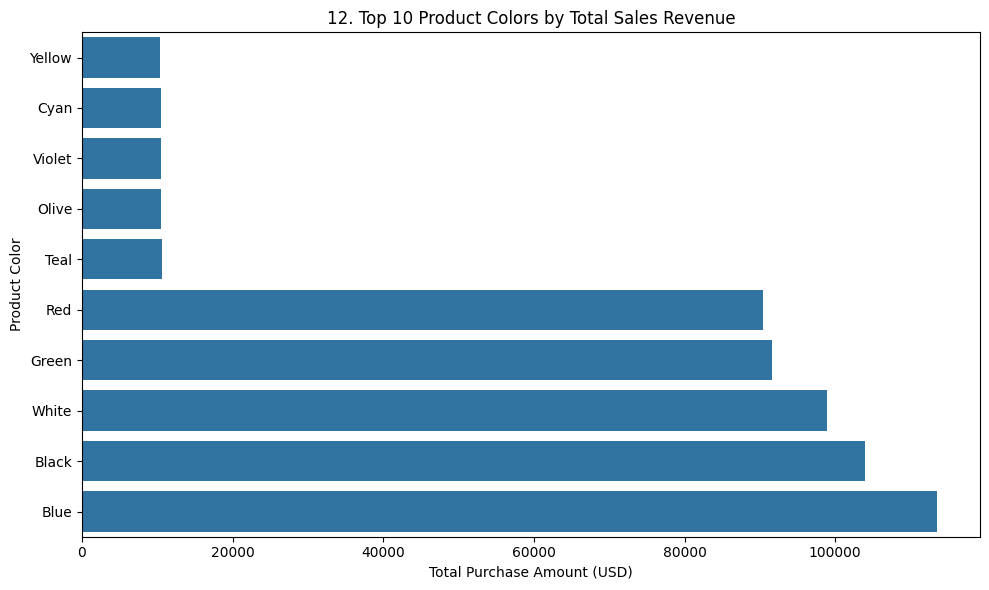

In [30]:
fig = plt.figure(figsize=(10,6))
color_sales = df.groupby('Color')['Purchase Amount (USD)'].sum().nlargest(10).sort_values()
sns.barplot(x=color_sales.values, y=color_sales.index)
plt.title(f'{plot_no}. Top 10 Product Colors by Total Sales Revenue')
plt.xlabel('Total Purchase Amount (USD)')
plt.ylabel('Product Color')
show_fig()
plot_no += 1

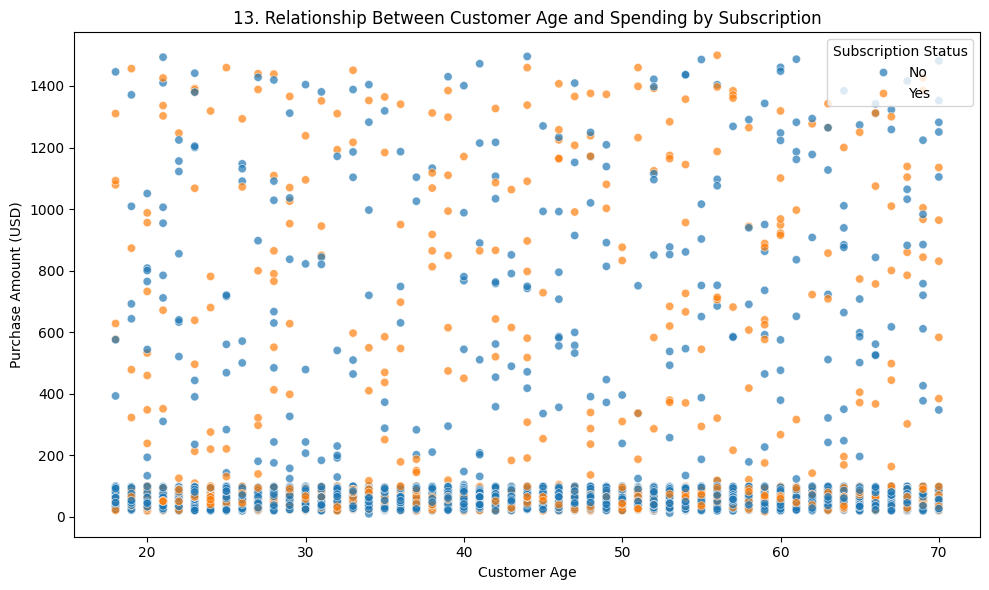

In [31]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Age', y='Purchase Amount (USD)', hue='Subscription Status', alpha=0.7)
plt.title(f'{plot_no}. Relationship Between Customer Age and Spending by Subscription')
plt.xlabel('Customer Age')
plt.ylabel('Purchase Amount (USD)')
show_fig()
plot_no += 1

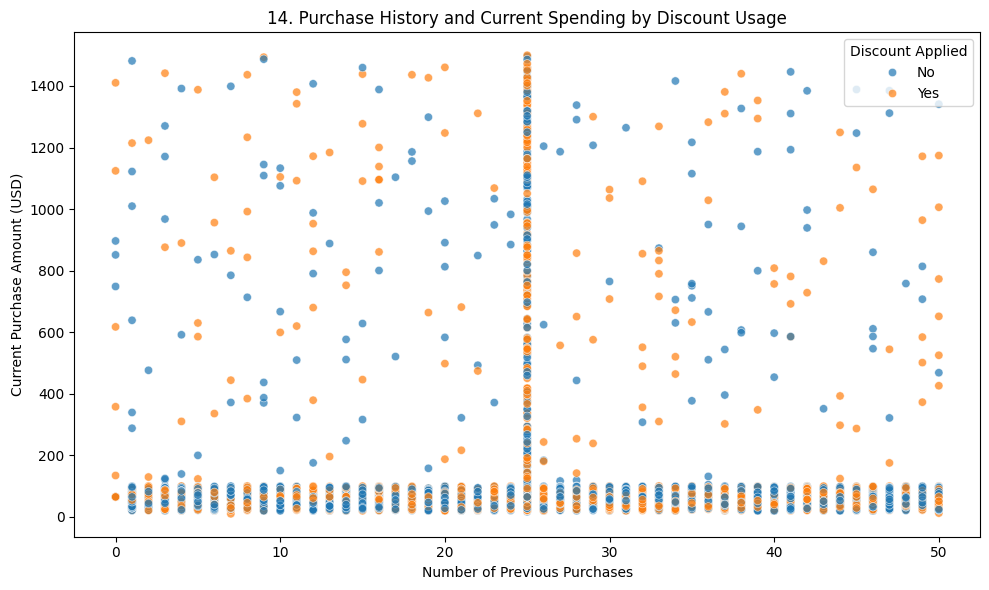

In [32]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Previous Purchases', y='Purchase Amount (USD)', hue='Discount Applied', alpha=0.7)
plt.title(f'{plot_no}. Purchase History and Current Spending by Discount Usage')
plt.xlabel('Number of Previous Purchases')
plt.ylabel('Current Purchase Amount (USD)')
show_fig()
plot_no += 1

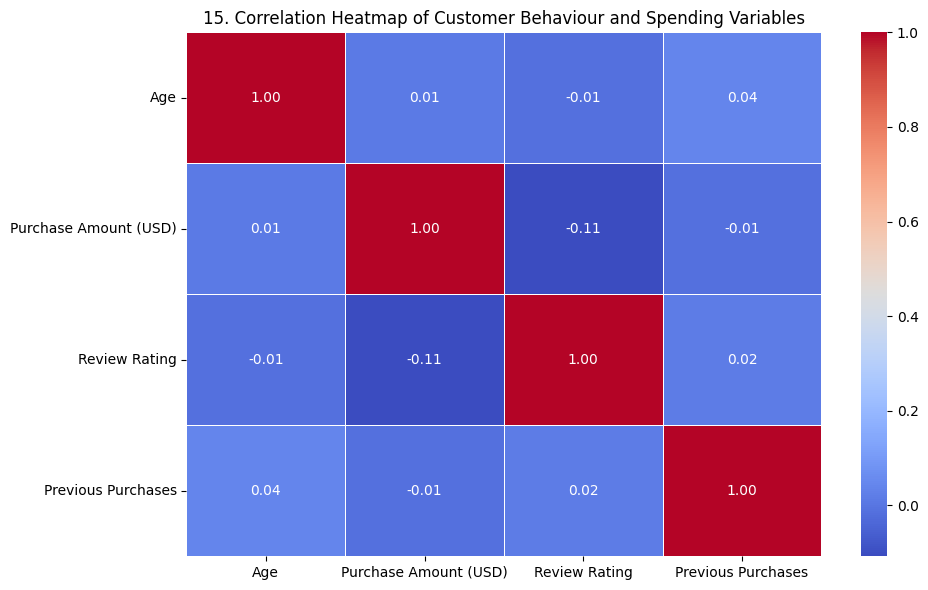

In [33]:
fig = plt.figure(figsize=(10,6))
corr = df[['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title(f'{plot_no}. Correlation Heatmap of Customer Behaviour and Spending Variables')
show_fig()
plot_no += 1

# Model Training

## select subscription status as target

In [34]:
target = 'Subscription Status'

## create input and target data

In [35]:
X = df.drop(columns=[target, 'Customer ID'])
y = df[target]

## identify numerical and categorical columns

In [36]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns

## create numerical preprocessing pipeline

In [37]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

## create categorical preprocessing pipeline

In [38]:
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

## combine preprocessing pipelines

In [39]:
preprocessor = ColumnTransformer([
    ('numerical', num_pipeline, num_cols),
    ('categorical', cat_pipeline, cat_cols)
])

## create logistic regression pipeline

In [40]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=42
    ))
])

## split data into training and testing sets

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## train the supervised learning model

In [42]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## predict subscription status

In [43]:
y_pred = model.predict(X_test)

## calculate model accuracy

In [44]:
accuracy = accuracy_score(y_test, y_pred)

## print rounded model accuracy

In [45]:
print(f'Model Accuracy: {round(accuracy * 100)}%')

Model Accuracy: 77%


## print detailed classification report

In [46]:
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred, zero_division=0))


Classification Report:

              precision    recall  f1-score   support

          No       0.94      0.71      0.81       692
         Yes       0.59      0.91      0.71       318

    accuracy                           0.77      1010
   macro avg       0.77      0.81      0.76      1010
weighted avg       0.83      0.77      0.78      1010



## display confusion matrix

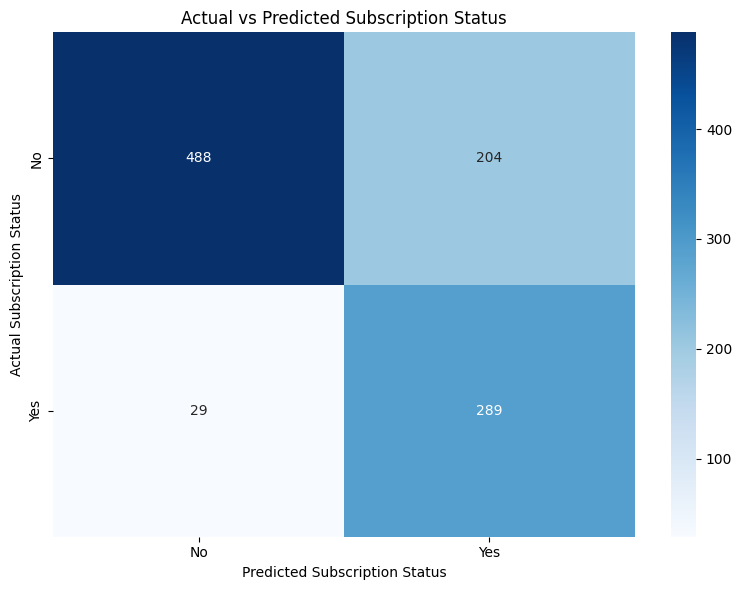

In [47]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=model.classes_,
    yticklabels=model.classes_
)
plt.title('Actual vs Predicted Subscription Status')
plt.xlabel('Predicted Subscription Status')
plt.ylabel('Actual Subscription Status')
plt.tight_layout()
plt.show()